## Setup

In [1]:
import numpy as np
import pandas as pd

from evaluation.plot_style import apply_plot_style
from models.nli.common import METRICS_DIR, DATA_DIR
from evaluation.nli.helpers import (
    load_metric_files,
    Q2QCalibration,
    to_model_score_data,
)
from evaluation.core import load_train_test_data

apply_plot_style()

## Load Best NLI Configuration

Configuration index 34 (`ttiitovdocsoe_nd_2026-03-01-15-25-31`) is rank \#1 by best
combined Pearson correlation (0.827).  Hypothesis template:
*"This text is {} in terms of visual details of characters, setting, or environment."*
Candidate labels: *not detailed / detailed*.

In [2]:
SELECTED_CONFIG_IDX = 34
MODEL_NAME_RAW = "richardr1126/roberta-base-zeroshot-v2.0-c-ONNX"
MODEL_NAME = "RoBERTa"

files = sorted(METRICS_DIR.glob("*.json"))
items = load_metric_files(files)
config_names = [f.stem for f in files]

df_train, df_test = load_train_test_data(DATA_DIR)
score_data = to_model_score_data(items, df_train, df_test)

sd = next(
    s
    for s in score_data
    if s.config_id == SELECTED_CONFIG_IDX and s.model_name == MODEL_NAME_RAW
)

print(f"Config : {config_names[SELECTED_CONFIG_IDX]}")
print(f"Model  : {MODEL_NAME}")
print(f"Train  : {len(sd.train_scores)} samples")
print(f"Test   : {len(sd.test_scores) if sd.test_scores is not None else 0} samples")

Config : ttiitovdocsoe_nd_2026-03-01-15-25-31
Model  : RoBERTa
Train  : 776 samples
Test   : 226 samples


## Calibrate (Q2Q) and Predict on Test Set

In [3]:
from utils import to_int_0_5

calibrator = Q2QCalibration().fit(sd.train_scores, sd.y_train)

test_pred_continuous = calibrator.predict(sd.test_scores)
y_true = to_int_0_5(sd.y_test)
y_pred = to_int_0_5(test_pred_continuous)

print(f"True label distribution : {dict(zip(*np.unique(y_true, return_counts=True)))}")
print(f"Pred label distribution : {dict(zip(*np.unique(y_pred, return_counts=True)))}")

True label distribution : {0: 51, 1: 33, 2: 51, 3: 65, 4: 24, 5: 2}
Pred label distribution : {0: 44, 1: 50, 2: 34, 3: 68, 4: 23, 5: 7}


## Test-Set Confusion Matrix

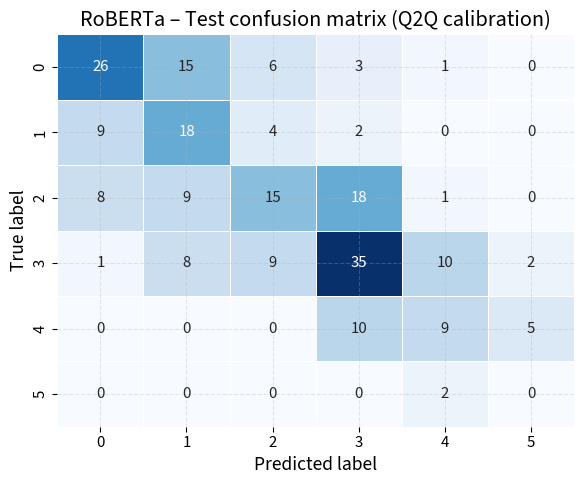


Raw matrix (rows=true, cols=pred):


,pred=0,pred=1,pred=2,pred=3,pred=4,pred=5
true=0,26,15,6,3,1,0
true=1,9,18,4,2,0,0
true=2,8,9,15,18,1,0
true=3,1,8,9,35,10,2
true=4,0,0,0,10,9,5
true=5,0,0,0,0,2,0


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels = list(range(6))
cm = confusion_matrix(y_true, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax,
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    cbar=False,
)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title(f"{MODEL_NAME} \u2013 Test confusion matrix (Q2Q calibration)")
plt.tight_layout()
plt.show()

print("\nRaw matrix (rows=true, cols=pred):")
display(
    pd.DataFrame(
        cm,
        index=[f"true={i}" for i in labels],
        columns=[f"pred={i}" for i in labels],
    )
)

## Ordered Miss Groups

Off-diagonal confusion-matrix cells sorted by count (most frequent misclassification first).

In [5]:
total_test = len(y_true)
total_correct = int(np.diag(cm).sum())
total_miss = total_test - total_correct

rows = []
for i in labels:
    for j in labels:
        if i == j:
            continue
        count = int(cm[i, j])
        if count == 0:
            continue
        rows.append(
            {
                "True": i,
                "Predicted": j,
                "Error (pred-true)": j - i,
                "Count": count,
                "% of misses": round(100 * count / total_miss, 1)
                if total_miss > 0
                else 0.0,
                "% of test": round(100 * count / total_test, 1),
            }
        )

df_misses = (
    pd.DataFrame(rows).sort_values("Count", ascending=False).reset_index(drop=True)
)
df_misses.index += 1

print(f"Total test samples : {total_test}")
print(
    f"Correct            : {total_correct}  ({100 * total_correct / total_test:.1f}%)"
)
print(f"Misclassified      : {total_miss}  ({100 * total_miss / total_test:.1f}%)\n")
print("Misclassification pairs ordered by frequency:")
display(df_misses)

Total test samples : 226
Correct            : 103  (45.6%)
Misclassified      : 123  (54.4%)

Misclassification pairs ordered by frequency:


,True,Predicted,Error (pred-true),Count,% of misses,% of test
1,2,3,1,18,14.6,8.0
2,0,1,1,15,12.2,6.6
3,3,4,1,10,8.1,4.4
4,4,3,-1,10,8.1,4.4
5,1,0,-1,9,7.3,4.0
6,2,1,-1,9,7.3,4.0
7,3,2,-1,9,7.3,4.0
8,2,0,-2,8,6.5,3.5
9,3,1,-2,8,6.5,3.5
10,0,2,2,6,4.9,2.7


## Miss Groups by Signed Error

Aggregate misses by `predicted - true`: negative = under-predicted, positive = over-predicted.

In [6]:
df_by_error = (
    df_misses.groupby("Error (pred-true)", as_index=False)
    .agg(Count=("Count", "sum"))
    .assign(**{"% of misses": lambda d: (100 * d["Count"] / total_miss).round(1)})
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
)
df_by_error.index += 1

print("Misses grouped by signed error (pred - true):")
display(df_by_error)

Misses grouped by signed error (pred - true):


,Error (pred-true),Count,% of misses
1,1,52,42.3
2,-1,39,31.7
3,-2,16,13.0
4,2,11,8.9
5,3,3,2.4
6,-3,1,0.8
7,4,1,0.8


## Segments from a Specific Miss Group

Set `TRUE_LABEL` and `PREDICTED_LABEL` to any pair from the miss table above.

In [17]:
def print_miss_group(true_label: int, predicted_label: int) -> None:
    mask = (y_true == true_label) & (y_pred == predicted_label)
    indices = np.where(mask)[0]
    texts = df_test["text"].iloc[indices].reset_index(drop=True)

    print(
        f"true={true_label} → predicted={predicted_label}  |  {len(texts)} segment(s)\n"
    )
    print("=" * 80)
    for i, text in enumerate(texts):
        print(f"[{i + 1}] {text}")
        print("-" * 80)


print_miss_group(0, 1)

true=0 → predicted=1  |  15 segment(s)

[1] meet them on Texas soil, and will promise them a fairer hearing than was
accorded me here to-day. Mr. Commissioner, I have always prided myself on
being a good citizen, have borne arms in defense of my country, and in
taking exception to your decision I brand you as the most despicable
member of The Western Supply Company. Any man who will prostitute a trust
for a money consideration—"
--------------------------------------------------------------------------------
[2] “'Come along now... pay your sixpences... pay your sixpences,” cried the man. He was through. He stepped at once into something that had for him all the elements of the most terrifying and enchanting of fairy tales.
--------------------------------------------------------------------------------
[3] There have been women all the time we've been married and he simply amuses himself with them until he's tired of them, and until the next one takes his fancy, and he does it quite o

<2 -> 3>
[1], [4], [5], [8], [9], [17]
<3 -> 2>
[1], [3], [8]
--> could be 3 if imaginative, however, the scene is not described enough to form a consistent image. The likely reason for this behavior is inconsistency in labelling, supported by the fact that 3/9 misclassifications in the opposite group (3 true, 2 predicted) show the same issue, only reversed. To remedy this, the annotation instructions could include this requirement in label (3) in the future. However these cases can be counted as inbetween scores 2 and 3, which is a limitation of the classification view, but likely taken into account on the real scale before rounding.

<2 -> 3>
[2] stream, [3] stream, [6] schooner, [10], [11], [12] Indian bead-work, [13] camps, dens, hiding-places, horde, avengers, wanderers, [14] blood-stained jewel, [16], [18]
--> too much weight on individual visualizable words that don't form a visualizable scene (some are scattered into multiple small scenes/perspectives). The preference of concrete scenes over visualizable words is explicitly formed by the instructions (both in the scale itself and a note on multiple perspectives), but the model struggles to learn this preference, suggesting the need for more training data to learn it. 

<0 -> 1>
[1], [7], [8], [9], [10], [14]
--> concrete words used to describe abstract and non-visual concepts
[11], [6], [13]
--> narrator reasoning behind character actions, character intentions in dialogue
[15], [12], [5]
--> non-sensical parts of dialogue

About third of the misclassifications of groups (3/4, 4/3) can be counted as inbetween the two classes, again likely taken into account on the real scale before rounding.
